# ML Experiment: Dimensionality Reduction for Phase and Frequency Classification

This notebook compares **PCA** (at various ranks) and **3D t-SNE** (via openTSNE) as input representations for a **Random Forest** classifier, applied to two prediction targets from PIV velocity snapshots:
- **Actuation phase** ($\phi = i \bmod 20$)
- **Actuation Strouhal number** ($St_{act}$)

We evaluate four tasks:
- **A**: Phase classification
- **B**: $St_{act}$ classification
- **C**: Joint $(\phi, St_{act})$ multi-output classification
- **D**: Generalization to unseen frequencies (leave-frequencies-out)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, sys, time, gc

sys.path.append(os.path.abspath('.'))
import ml_experiment_utils as mlu

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)

os.makedirs('figures', exist_ok=True)
os.makedirs('pca_data', exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Data Preparation: Global IncrementalPCA

Each PIV snapshot has $2 \times 269 \times 319 = 171{,}622$ features (fluctuating $u$ and $v$ velocity components). To make this tractable, we compute a **global IncrementalPCA** across all 24 forced runs (48,720 snapshots), retaining 500 components.

The IncrementalPCA streams one run at a time into memory, avoiding the need to load all ~60 GB of raw data simultaneously. Phase labels are assigned as $\phi_i = i \bmod 20$, reflecting the 20 snapshots per actuation cycle.

In [4]:
# Compute or load the global PCA scores for all 24 forced runs
pca_scores, run_labels, st_labels, phase_labels = mlu.load_or_compute_global_pca(
    compressed_data_dir='compressed_data',
    output_path='pca_data/global_forced_pca.npz'
)

print(f'PCA scores shape: {pca_scores.shape}')
print(f'Unique runs: {np.unique(run_labels)}')
print(f'Unique St values: {np.unique(st_labels)}')
print(f'Unique phases: {np.unique(phase_labels)}')

Computing global IncrementalPCA (500 components)...
--- PASS 1: Fitting IncrementalPCA ---
  Fitting RUN 2...
  Fitting RUN 3...
  Fitting RUN 4...
  Fitting RUN 5...
  Fitting RUN 6...
  Fitting RUN 7...
  Fitting RUN 8...
  Fitting RUN 9...
  Fitting RUN 10...
  Fitting RUN 11...
  Fitting RUN 12...
  Fitting RUN 13...
  Fitting RUN 14...
  Fitting RUN 15...
  Fitting RUN 16...
  Fitting RUN 17...
  Fitting RUN 18...
  Fitting RUN 19...
  Fitting RUN 20...
  Fitting RUN 21...
  Fitting RUN 22...
  Fitting RUN 23...
  Fitting RUN 24...
  Fitting RUN 25...

Total variance explained by 500 components: 96.51%

--- PASS 2: Extracting PCA Scores ---
  Transforming RUN 2...
  Transforming RUN 3...
  Transforming RUN 4...
  Transforming RUN 5...
  Transforming RUN 6...
  Transforming RUN 7...
  Transforming RUN 8...
  Transforming RUN 9...
  Transforming RUN 10...
  Transforming RUN 11...
  Transforming RUN 12...
  Transforming RUN 13...
  Transforming RUN 14...
  Transforming RUN 15...
  Tr

## 2. Train/Test Splits

We create two separate splits:

1. **Standard split** (Tasks A, B, C): Stratified 80/20 random split on the combined $(St_{act}, \phi)$ label, ensuring proportional representation of all class combinations.

2. **Leave-frequencies-out split** (Task D): Hold out 4 entire runs ($St = 0.15, 0.45, 0.75, 1.05$) for testing. The model is trained on the remaining 20 runs and must generalize to unseen frequencies.

In [2]:
data = np.load('pca_data/global_forced_pca.npz')
pca_scores   = data['pca_scores']    # (48720, 500)
run_labels   = data['run_labels']    # (48720,)
st_labels    = data['st_labels']     # (48720,)
phase_labels = data['phase_labels']  # (48720,)


# --- Standard split (Tasks A, B, C) ---
std_train_idx, std_test_idx = mlu.create_standard_split(
    pca_scores, phase_labels, st_labels
)
print(f'Standard split: {len(std_train_idx)} train, {len(std_test_idx)} test')

# --- Leave-frequencies-out split (Task D) ---
lfo_train_idx, lfo_test_idx = mlu.create_leave_freq_out_split(run_labels)
print(f'Leave-freq-out split: {len(lfo_train_idx)} train, {len(lfo_test_idx)} test')
print(f'  Held-out runs: {mlu.HELD_OUT_RUNS}')
print(f'  Held-out St values: {[mlu.ST_INFO[r] for r in mlu.HELD_OUT_RUNS]}')

Standard split: 38976 train, 9744 test
Leave-freq-out split: 40600 train, 8120 test
  Held-out runs: [4, 10, 16, 22]
  Held-out St values: [0.15, 0.45, 0.75, 1.05]


## 3. t-SNE Embedding with openTSNE

Unlike scikit-learn's implementation, `openTSNE` provides a `transform()` method for out-of-sample data. This works by:
1. Finding the new point's $k$ nearest neighbors in the **original high-dimensional training data**
2. Initializing its low-dimensional position via weighted interpolation of neighbors' embeddings
3. Optionally refining via gradient descent (keeping training embeddings fixed)

We fit t-SNE **only on training data** for each split, then transform the test data. This avoids data leakage.

In [3]:
# t-SNE for the STANDARD split
print('=== Standard Split t-SNE ===')
std_tsne_train, std_tsne_test, std_tsne_fit_t, std_tsne_transform_t = \
    mlu.fit_and_transform_tsne(
        pca_scores[std_train_idx],
        pca_scores[std_test_idx],
        n_components=3, perplexity=50
    )
print(f'Train embedding: {std_tsne_train.shape}, Test embedding: {std_tsne_test.shape}')

=== Standard Split t-SNE ===
Fitting openTSNE (n_components=3, perplexity=50) on 38976 samples with 500 features...
--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_components=3, n_jobs=-1,
     negative_gradient_method='bh', perplexity=50, random_state=42,
     verbose=True)
--------------------------------------------------------------------------------
===> Finding 150 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 23.74 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.69 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.28 seconds
===> Running optimization with exaggeration=12.00, lr=3248.00 for 250 iterations...
Iteration   50, KL divergence    nan, 50 iterations in 74.7784 sec
Iteration  100, KL divergence    nan, 50 iterations in 5.1680 sec
Iteration  150, KL divergence    nan, 50 iterations in 5.2632 sec
Iteration  200, KL 

In [4]:
# t-SNE for the LEAVE-FREQUENCIES-OUT split
print('=== Leave-Freq-Out t-SNE ===')
lfo_tsne_train, lfo_tsne_test, lfo_tsne_fit_t, lfo_tsne_transform_t = \
    mlu.fit_and_transform_tsne(
        pca_scores[lfo_train_idx],
        pca_scores[lfo_test_idx],
        n_components=3, perplexity=50
    )
print(f'Train embedding: {lfo_tsne_train.shape}, Test embedding: {lfo_tsne_test.shape}')

=== Leave-Freq-Out t-SNE ===
Fitting openTSNE (n_components=3, perplexity=50) on 40600 samples with 500 features...
--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_components=3, n_jobs=-1,
     negative_gradient_method='bh', perplexity=50, random_state=42,
     verbose=True)
--------------------------------------------------------------------------------
===> Finding 150 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 22.08 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.55 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.15 seconds
===> Running optimization with exaggeration=12.00, lr=3383.33 for 250 iterations...
Iteration   50, KL divergence    nan, 50 iterations in 99.6163 sec
Iteration  100, KL divergence    nan, 50 iterations in 5.4826 sec
Iteration  150, KL divergence    nan, 50 iterations in 5.2966 sec
Iteration  200, KL 

## 4. Tasks A, B, C — Standard Classification

For each representation (PCA-10, PCA-50, PCA-100, PCA-200, PCA-500, t-SNE-3D) and each Random Forest complexity level (Low, Medium, High), we train and evaluate:

- **Task A**: Phase classification (20 classes)
- **Task B**: $St_{act}$ classification (24 classes)
- **Task C**: Joint multi-output classification (exact match ratio)

In [5]:
# Build representations for standard split
std_reps = mlu.build_representations(
    pca_scores[std_train_idx], pca_scores[std_test_idx],
    std_tsne_train, std_tsne_test
)

# Run all standard experiments
print('Running Tasks A, B, C...')
std_results = mlu.run_all_standard_experiments(
    std_reps,
    phase_labels[std_train_idx], phase_labels[std_test_idx],
    st_labels[std_train_idx], st_labels[std_test_idx]
)

Running Tasks A, B, C...

  [PCA-10 | Low]  A:0.134  B:0.274  C:0.110
  [PCA-10 | Medium]  A:0.402  B:0.657  C:0.389
  [PCA-10 | High]  A:0.494  B:0.713  C:0.460
  [PCA-50 | Low]  A:0.169  B:0.337  C:0.116
  [PCA-50 | Medium]  A:0.418  B:0.831  C:0.468
  [PCA-50 | High]  A:0.473  B:0.917  C:0.549
  [PCA-100 | Low]  A:0.161  B:0.315  C:0.100
  [PCA-100 | Medium]  A:0.378  B:0.833  C:0.414
  [PCA-100 | High]  A:0.400  B:0.925  C:0.483
  [PCA-200 | Low]  A:0.155  B:0.308  C:0.111
  [PCA-200 | Medium]  A:0.316  B:0.817  C:0.354
  [PCA-200 | High]  A:0.326  B:0.920  C:0.408
  [PCA-500 | Low]  A:0.137  B:0.263  C:0.088
  [PCA-500 | Medium]  A:0.257  B:0.775  C:0.286
  [PCA-500 | High]  A:0.255  B:0.911  C:0.304
  [t-SNE-3D | Low]  A:0.051  B:0.041  C:0.002
  [t-SNE-3D | Medium]  A:0.051  B:0.041  C:0.002
  [t-SNE-3D | High]  A:0.050  B:0.041  C:0.002
Done.


In [6]:
# Display results as a DataFrame
df_std = pd.DataFrame(std_results)
display(df_std.round(4))

,task,representation,complexity,accuracy,f1_macro,train_time,inference_time,inference_time_per_sample,total_nodes,accuracy_phase,accuracy_st,f1_phase,f1_st,exact_match
0,A (Phase),PCA-10,Low,0.1337,0.1516,0.2583,0.0291,0.0000,376,NaN,NaN,NaN,NaN,NaN
1,B (St_act),PCA-10,Low,0.2736,0.2182,0.2435,0.0319,0.0000,502,NaN,NaN,NaN,NaN,NaN
2,C (Joint),PCA-10,Low,NaN,NaN,0.3461,0.0326,0.0000,582,0.1565,0.2560,0.1741,0.2066,0.1103
3,A (Phase),PCA-10,Medium,0.4021,0.4047,6.5312,0.1087,0.0000,213330,NaN,NaN,NaN,NaN,NaN
4,B (St_act),PCA-10,Medium,0.6573,0.6400,6.3894,0.1221,0.0000,477832,NaN,NaN,NaN,NaN,NaN
5,C (Joint),PCA-10,Medium,NaN,NaN,8.8320,0.2032,0.0000,675168,0.4418,0.6506,0.4428,0.6310,0.3894
6,A (Phase),PCA-10,High,0.4943,0.4940,48.8434,0.6682,0.0001,12730176,NaN,NaN,NaN,NaN,NaN
7,B (St_act),PCA-10,High,0.7126,0.6999,38.1363,0.6244,0.0001,8792940,NaN,NaN,NaN,NaN,NaN
8,C (Joint),PCA-10,High,NaN,NaN,64.5155,21.3679,0.0022,14618898,0.4952,0.7137,0.4949,0.7001,0.4596
9,A (Phase),PCA-50,Low,0.1690,0.1705,0.7206,0.0314,0.0000,482,NaN,NaN,NaN,NaN,NaN


### Interpretation

*[To be written after examining the results above. Analyze accuracy vs. dimensionality trends, compare t-SNE-3D against PCA at similar dimensions, and assess the accuracy-complexity trade-off.]*

## 5. Task D — Generalization to Unseen Frequencies

We test whether the representations capture the **continuous parametric structure** of the flow by holding out 4 runs ($St = 0.15, 0.45, 0.75, 1.05$) and evaluating:

- **D.1**: $St_{act}$ **regression** — can the model interpolate to frequencies it has never seen? (Measured by MAE, RMSE, $R^2$)
- **D.2**: Phase **classification** — does the phase structure learned at neighboring frequencies transfer to unseen ones?

In [7]:
# Build representations for leave-frequencies-out split
lfo_reps = mlu.build_representations(
    pca_scores[lfo_train_idx], pca_scores[lfo_test_idx],
    lfo_tsne_train, lfo_tsne_test
)

# Run generalization experiments
print('Running Task D (generalization)...')
gen_results = mlu.run_all_generalization_experiments(
    lfo_reps,
    phase_labels[lfo_train_idx], phase_labels[lfo_test_idx],
    st_labels[lfo_train_idx], st_labels[lfo_test_idx]
)

Running Task D (generalization)...

  [PCA-10 | Low]  D1-R2:0.572  D2:0.051
  [PCA-10 | Medium]  D1-R2:0.764  D2:0.061
  [PCA-10 | High]  D1-R2:0.784  D2:0.077
  [PCA-50 | Low]  D1-R2:0.565  D2:0.070
  [PCA-50 | Medium]  D1-R2:0.668  D2:0.096
  [PCA-50 | High]  D1-R2:0.694  D2:0.097
  [PCA-100 | Low]  D1-R2:0.563  D2:0.057
  [PCA-100 | Medium]  D1-R2:0.679  D2:0.080
  [PCA-100 | High]  D1-R2:0.703  D2:0.079
  [PCA-200 | Low]  D1-R2:0.564  D2:0.056
  [PCA-200 | Medium]  D1-R2:0.671  D2:0.081
  [PCA-200 | High]  D1-R2:0.699  D2:0.084
  [PCA-500 | Low]  D1-R2:0.563  D2:0.083
  [PCA-500 | Medium]  D1-R2:0.671  D2:0.080
  [PCA-500 | High]  D1-R2:0.697  D2:0.080
  [t-SNE-3D | Low]  D1-R2:-0.008  D2:0.050
  [t-SNE-3D | Medium]  D1-R2:-0.008  D2:0.050
  [t-SNE-3D | High]  D1-R2:-0.008  D2:0.050
Done.


In [8]:
# Display generalization results
df_gen = pd.DataFrame(gen_results)
display(df_gen.round(4))

,task,representation,complexity,mae,rmse,r2,train_time,inference_time,inference_time_per_sample,total_nodes,accuracy,f1_macro
0,D.1 (St regression),PCA-10,Low,0.1720,0.2194,0.5723,0.5863,0.0335,0.0000,622,NaN,NaN
1,D.2 (Phase transfer),PCA-10,Low,NaN,NaN,NaN,0.3053,0.0310,0.0000,290,0.0506,0.0289
2,D.1 (St regression),PCA-10,Medium,0.1306,0.1628,0.7644,16.1372,0.0764,0.0000,556556,NaN,NaN
3,D.2 (Phase transfer),PCA-10,Medium,NaN,NaN,NaN,7.7689,0.1086,0.0000,210798,0.0608,0.0611
4,D.1 (St regression),PCA-10,High,0.1251,0.1560,0.7836,104.3490,0.2483,0.0000,8616000,NaN,NaN
5,D.2 (Phase transfer),PCA-10,High,NaN,NaN,NaN,52.7239,0.5908,0.0001,13790972,0.0775,0.0763
6,D.1 (St regression),PCA-50,Low,0.1726,0.2212,0.5652,2.7539,0.0312,0.0000,626,NaN,NaN
7,D.2 (Phase transfer),PCA-50,Low,NaN,NaN,NaN,0.5281,0.0297,0.0000,460,0.0702,0.0618
8,D.1 (St regression),PCA-50,Medium,0.1578,0.1932,0.6681,75.5568,0.0617,0.0000,454746,NaN,NaN
9,D.2 (Phase transfer),PCA-50,Medium,NaN,NaN,NaN,14.2115,0.1076,0.0000,674404,0.0964,0.0969


### Interpretation

*[To be written after examining the results above. Focus on whether the Random Forest regressor can interpolate St_act for unseen runs, and whether phase structure transfers across frequencies.]*

## 6. Visualization

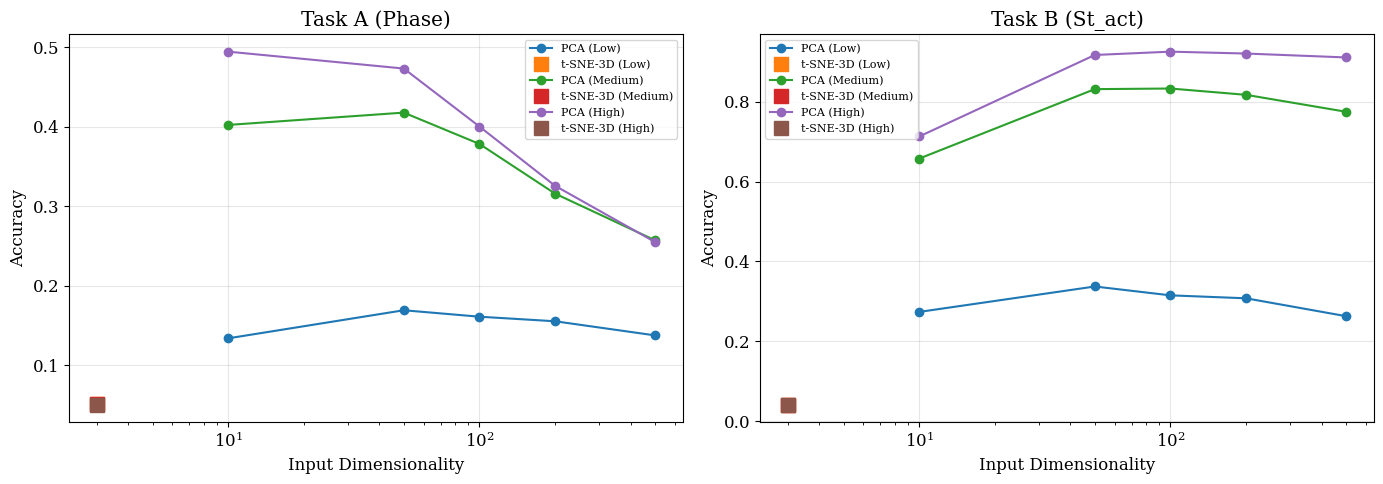

In [9]:
# === Accuracy vs. Dimensionality (Tasks A, B) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_name in zip(axes, ['A (Phase)', 'B (St_act)']):
    df_task = df_std[df_std['task'] == task_name]
    
    for level in ['Low', 'Medium', 'High']:
        df_level = df_task[df_task['complexity'] == level]
        
        # PCA points (with x = dimensionality)
        pca_rows = df_level[df_level['representation'].str.startswith('PCA')]
        dims = [int(r.split('-')[1]) for r in pca_rows['representation']]
        ax.plot(dims, pca_rows['accuracy'], 'o-', label=f'PCA ({level})')
        
        # t-SNE point
        tsne_row = df_level[df_level['representation'] == 't-SNE-3D']
        if len(tsne_row) > 0:
            ax.plot(3, tsne_row['accuracy'].values[0], 's', markersize=10,
                    label=f't-SNE-3D ({level})')
    
    ax.set_xlabel('Input Dimensionality')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Task {task_name}')
    ax.legend(fontsize=8)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/accuracy_vs_dimensionality.png', dpi=300, bbox_inches='tight')
plt.show()

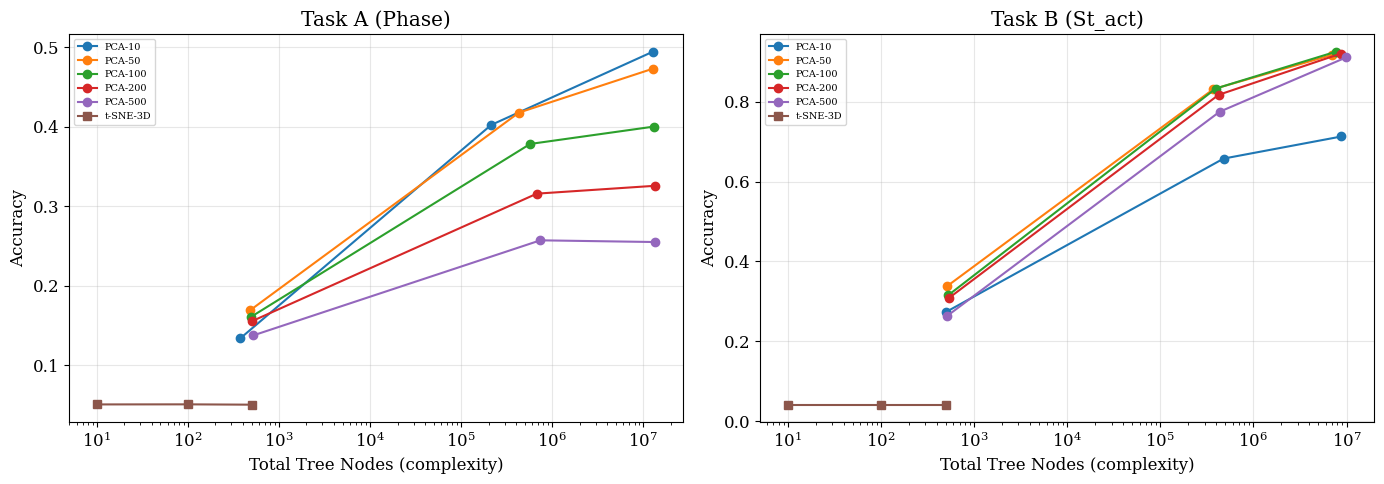

In [10]:
# === Accuracy vs. Model Complexity (total node count) ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_name in zip(axes, ['A (Phase)', 'B (St_act)']):
    df_task = df_std[df_std['task'] == task_name]
    
    for rep in df_task['representation'].unique():
        df_rep = df_task[df_task['representation'] == rep]
        marker = 's' if rep == 't-SNE-3D' else 'o'
        ax.plot(df_rep['total_nodes'], df_rep['accuracy'], marker=marker,
                label=rep, markersize=6)
    
    ax.set_xlabel('Total Tree Nodes (complexity)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Task {task_name}')
    ax.legend(fontsize=7)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/accuracy_vs_complexity.png', dpi=300, bbox_inches='tight')
plt.show()

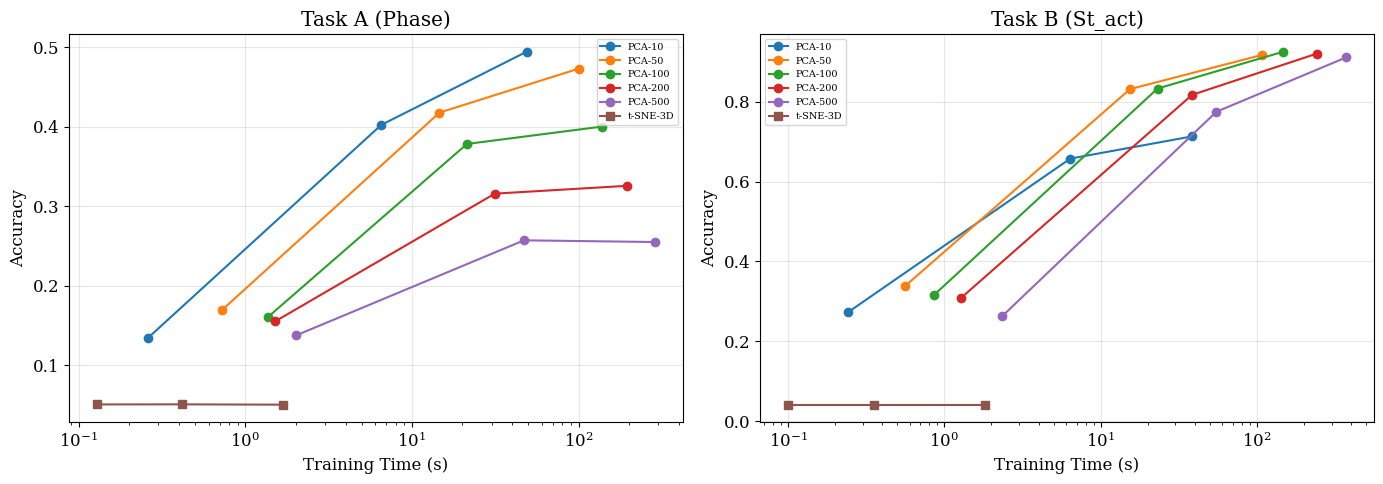

In [11]:
# === Accuracy vs. Training Time ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task_name in zip(axes, ['A (Phase)', 'B (St_act)']):
    df_task = df_std[df_std['task'] == task_name]
    
    for rep in df_task['representation'].unique():
        df_rep = df_task[df_task['representation'] == rep]
        marker = 's' if rep == 't-SNE-3D' else 'o'
        ax.plot(df_rep['train_time'], df_rep['accuracy'], marker=marker,
                label=rep, markersize=6)
    
    ax.set_xlabel('Training Time (s)')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Task {task_name}')
    ax.legend(fontsize=7)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/accuracy_vs_training_time.png', dpi=300, bbox_inches='tight')
plt.show()

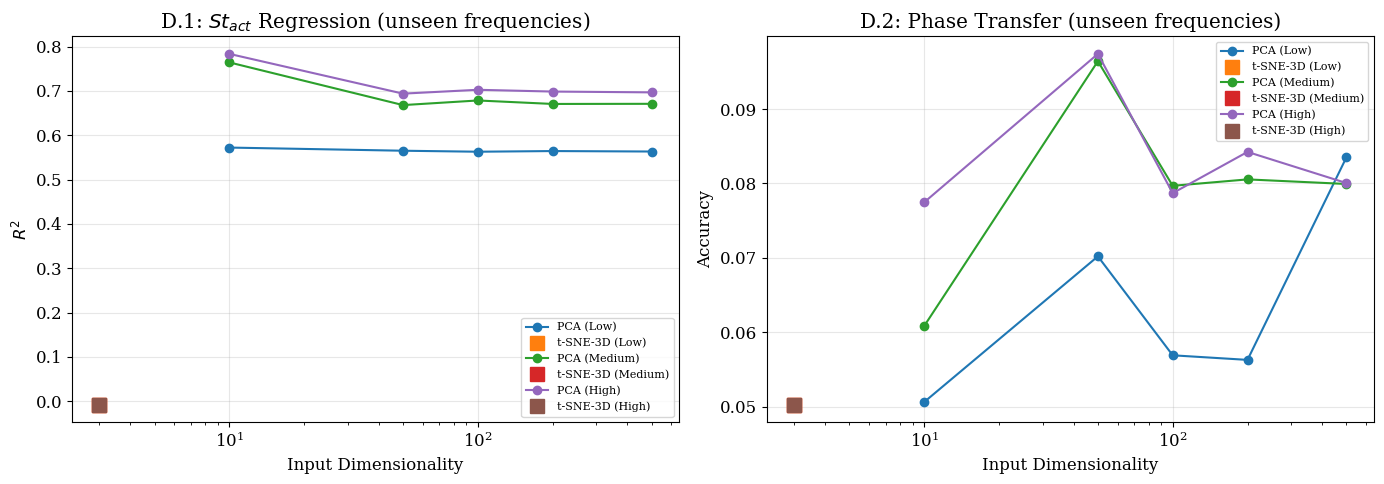

In [12]:
# === Generalization: R^2 vs. Dimensionality for St regression ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# D.1: St regression R^2
ax = axes[0]
df_d1 = df_gen[df_gen['task'] == 'D.1 (St regression)']
for level in ['Low', 'Medium', 'High']:
    df_level = df_d1[df_d1['complexity'] == level]
    pca_rows = df_level[df_level['representation'].str.startswith('PCA')]
    dims = [int(r.split('-')[1]) for r in pca_rows['representation']]
    ax.plot(dims, pca_rows['r2'], 'o-', label=f'PCA ({level})')
    tsne_row = df_level[df_level['representation'] == 't-SNE-3D']
    if len(tsne_row) > 0:
        ax.plot(3, tsne_row['r2'].values[0], 's', markersize=10,
                label=f't-SNE-3D ({level})')
ax.set_xlabel('Input Dimensionality')
ax.set_ylabel('$R^2$')
ax.set_title('D.1: $St_{act}$ Regression (unseen frequencies)')
ax.legend(fontsize=8)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# D.2: Phase transfer accuracy
ax = axes[1]
df_d2 = df_gen[df_gen['task'] == 'D.2 (Phase transfer)']
for level in ['Low', 'Medium', 'High']:
    df_level = df_d2[df_d2['complexity'] == level]
    pca_rows = df_level[df_level['representation'].str.startswith('PCA')]
    dims = [int(r.split('-')[1]) for r in pca_rows['representation']]
    ax.plot(dims, pca_rows['accuracy'], 'o-', label=f'PCA ({level})')
    tsne_row = df_level[df_level['representation'] == 't-SNE-3D']
    if len(tsne_row) > 0:
        ax.plot(3, tsne_row['accuracy'].values[0], 's', markersize=10,
                label=f't-SNE-3D ({level})')
ax.set_xlabel('Input Dimensionality')
ax.set_ylabel('Accuracy')
ax.set_title('D.2: Phase Transfer (unseen frequencies)')
ax.legend(fontsize=8)
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/generalization_results.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Final Interpretation

*[To be written after examining all results and plots above. Key questions to address:]*

*1. At what PCA dimensionality does classification accuracy saturate?*

*2. How does t-SNE-3D compare to PCA at similar or higher dimensionality?*

*3. What is the accuracy–complexity trade-off? Can a simpler model on reduced data match a complex model on full PCA?*

*4. Does the representation encode a smooth frequency manifold (Task D.1)?*

*5. Does phase structure generalize across frequencies (Task D.2)?*